In [1]:
import os
import re
from scripts.cvrp_lp_greedy import solve_cvrp_lp as solve_cvrp_lp_greedy
from scripts.cvrp_lp_probabilistic import solve_cvrp_lp_probabilistic as solve_csrp_lp_prob

from scripts.plot_utils import plot_cbc_log, plot_ga_log, plot_hybrid_log

# Funkcje pomocnicze

In [2]:
def get_optimal_cost(vrp_filepath):
    sol_filepath = vrp_filepath.replace('.vrp', '.sol')
    if os.path.exists(sol_filepath):
        with open(sol_filepath, 'r') as f:
            for line in f:
                if line.startswith('Cost'):
                    match = re.search(r'Cost\s+(\d+)', line)
                    if match:
                        return float(match.group(1))
    return None


def run_experiments(instances, solver_function, **kwargs):
    for inst in instances:
        if os.path.exists(inst):
            try:
                opt_cost = get_optimal_cost(inst)
                solver_function(inst, **kwargs)
                func_name = solver_function.__name__

                if func_name == 'solve_cvrp_ga':
                    plot_ga_log(optimum_cost=opt_cost)
                    
                elif func_name in ['solve_cvrp_hybrid', 'solve_cvrp_hybrid_candidate']:
                    plot_hybrid_log(optimum_cost=opt_cost)

                elif func_name in ['solve_cvrp_ilp', 'solve_cvrp_ilp_opt']: 
                    plot_cbc_log(f"cbc_solver_{os.getpid()}.log", optimum_cost=opt_cost)
                    
                elif func_name == 'solve_cvrp_lp':
                    print("Zakończono algorytm LP. Brak logu CBC do narysowania.")

            except Exception as e:
                print(f"Błąd podczas analizy {inst}: {e}")
        else:
            print(f"Plik {inst} nie istnieje!")

# Instancje

In [3]:
instances = [
    os.path.join('data', 'E', 'E-n23-k3.vrp')
]

# Algorytm LP Greedy

Wczytano 22 klientów, depot: 1, pojemność: 4500, maks. ciężarówek: 3
Uruchamianie solvera
Czas wykonania: 0.12 s
Status: Optimal
Minimal tour: 388.41444467160005
Przekroczony limit pojazdów. Mamy 4 fragmentów. Limit to 3. Dopychanie geometryczne.
Otrzymano wymagane ograniczenie na liczbę pojazdów.
Zapisano statystyki eksperymentu do results/experiments.csv


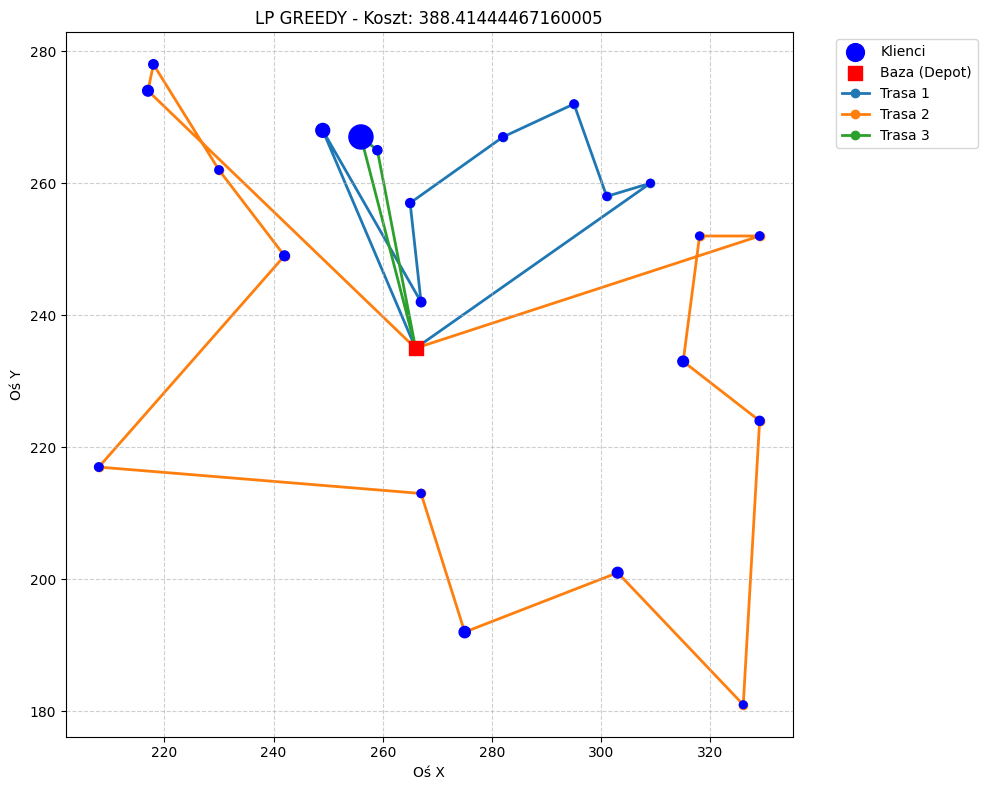

Zakończono algorytm LP. Brak logu CBC do narysowania.


In [4]:
run_experiments(instances, solve_cvrp_lp_greedy, time_limit=60)

# Algorytm Losowy

Wczytano 22 klientów, depot: 1, pojemność: 4500, maks. ciężarówek: 3
Uruchamianie solvera
Czas wykonania: 0.04 s
Status: Optimal
Teoretyczne minimum (ułamkowe LP): 388.41
Rozpoczynam zrandomizowane budowanie tras (100 iteracji)...
Najlepszy koszt znaleziony metodą probabilistyczną: 619
Zbudowano pojazdów: 3
Zapisano statystyki eksperymentu do results/experiments.csv


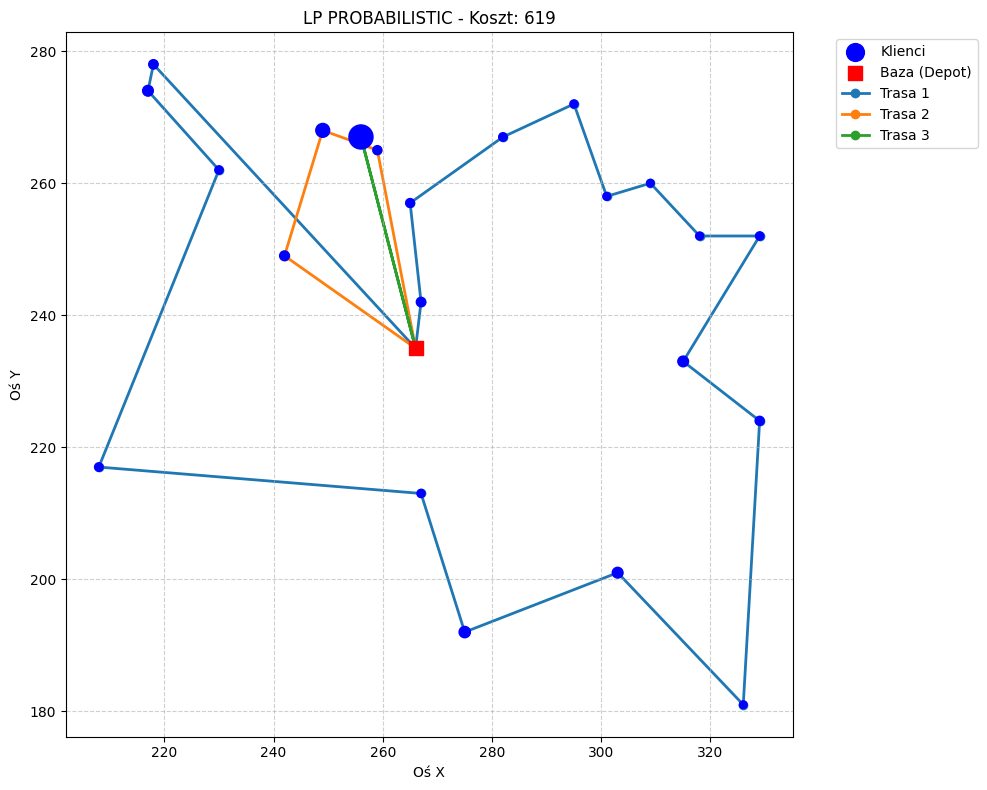

In [5]:
run_experiments(instances, solve_csrp_lp_prob, time_limit=60, num_iterations=100)